In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

**Table of contents**<a id='toc0_'></a>    
- 1. [CHUẨN BỊ DỮ LIỆU MÔ PHỎNG](#toc1_)    
  - 1.1. [Giới thiệu dữ liệu gốc](#toc1_1_)    
  - 1.2. [EDA](#toc1_2_)    
    - 1.2.1. [Khảo sát phân bố (distribution)](#toc1_2_1_)    
    - 1.2.2. [Khảo sát mức tương quan tuyến tính (Correlation)](#toc1_2_2_)    
    - 1.2.3. [Quan sát kỹ hơn tương quan tuyến tính](#toc1_2_3_)    
- 2. [CHUẨN BỊ VÀ TIỀN XỬ LÝ](#toc2_)    
  - 2.1. [Tiền xử lý](#toc2_1_)    
  - 2.2. [Chia train-test](#toc2_2_)    
  - 2.3. [Chuẩn bị hàm chạy k-fold](#toc2_3_)    
  - 2.4. [Optuna Tuning Wrapper](#toc2_4_)    
- 3. [HUẨN LUYỆN MODEL (!!!)](#toc3_)    
  - 3.1. [Random Forest - Test R2: 0.66](#toc3_1_)    
  - 3.2. [XGBoost - Test R2: 0.5](#toc3_2_)    
  - 3.3. [SVR (Support Vector) - Test R2: 0.68](#toc3_3_)    
  - 3.4. [AdaBoost - Test R2: 0.64](#toc3_4_)    
- 4. [PHÂN TÍCH MODEL](#toc4_)    
  - 4.1. [SHAP (SHapley Additive exPlanations)](#toc4_1_)    
    - 4.1.1. [Tính local SHAP](#toc4_1_1_)    
    - 4.1.2. [Biểu đồ](#toc4_1_2_)    
  - 4.2. [Thử nghiệm với bộ dữ liệu khác](#toc4_2_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[CHUẨN BỊ DỮ LIỆU MÔ PHỎNG](#toc0_)

## 1.1. <a id='toc1_1_'></a>[Giới thiệu dữ liệu gốc](#toc0_)

Bộ dữ liệu bao gồm: 

- <strong>Features</strong>:
  - <strong>Antimony Content (AC)</strong>: Hàm lượng Antimony trong hợp chất Sb@C
  - <strong>Antimony Size (AS)</strong>: Kích thước hạt Antimony (Sb)
  - <strong>Raman peak (RP)</strong>:  Tỷ lệ cường độ đỉnh Raman ($I_D/I_G$). Đại lượng này phản ánh mức độ khuyết tật (defects) và độ graphit hóa của vật liệu carbon.
  - <strong>Interplanar Spacing (IS)</strong>: Khoảng cách giữa các mặt phẳng tinh thể (d-spacing)
  - <strong>Nitrogen (N)</strong>: Biến phân loại (0/1) liệu mẫu có pha tạp Nitơ hay không?
  - <strong>Initial Capacity (IC)</strong>: Mức lưu trữ điện năng (capacity) ban đầu.
  - <strong>Degree of Crystallinity (DC)</strong>: Độ kết tinh của vật liệu carbon

- <strong>Target</strong>:
  - <strong>Remaining Capacity (RC)</strong>: Mức lưu trữ còn lại sau 100 chu kỳ (cycle)

- <strong>Besides</strong>:
  - <strong>DOI</strong>: mã định danh của nguồn dữ liệu gốc được tổng hợp

In [3]:
data = pd.read_csv('./input/Sb@C-main.csv')
data = data.drop(columns=["DOI"])

full_name = {
    'AC': 'Antimony Content',
    'AS': 'Antimony Size',
    'RP': 'Raman Peak',
    'IS': 'Interplanar Spacing',
    'N': 'Nitrogen',
    'DC': 'Degree of Crystallinity',
    'IC': 'Initial Capacity',

    'RC': 'Remain Capacity'
}

# Tách Features (X) và Target (y)
X = data[['AC', 'AS', 'RP', 'IS', 'N', 'IC', 'DC']]
y = data['RC']

data

,AS,IS,DC,RP,N,AC,IC,RC
0,7.5,0.215,3.50,1.31,1,0.070,460.00,362.0
1,30.0,0.310,1.67,0.72,0,0.550,329.94,401.0
2,NaN,0.310,3.46,NaN,0,0.748,430.00,380.0
3,10.0,0.225,2.62,0.97,1,0.790,471.00,405.0
4,30.0,0.310,4.28,1.08,1,0.350,560.00,543.0
...,...,...,...,...,...,...,...,...
85,20.0,0.320,2.93,0.95,0,0.780,540.40,540.5
86,NaN,0.310,3.75,0.80,1,0.670,619.20,568.9
87,290.0,0.310,2.17,1.27,0,0.490,531.76,423.0
88,150.0,0.220,4.50,0.89,1,0.570,430.80,400.9


## 1.2. <a id='toc1_2_'></a>[EDA](#toc0_)
** Nhận xét:
- Chủ yếu thông tin thu nạp được là về phân bố của dữ liệu

- Lượng dữ liệu có khá ít, 90 samples, khó có thể khẳng định được độ sạch hay độ tổng quát của dataset. Trong đó, mỗi cột đều ít nhiều bị khuyết giá trị (NaN). Việc fillna sẽ cần được xem xét khi một số model không có khả năng xử lý NaN, hoặc tìm được cách filling hiệu quả để làm sạch dữ liệu.

- Đặc trưng cho thấy mức độ tương đồng cao với target (Remain Capacity - RC) là Antimony Content (AC) và Initial Capacity (IC). Mặc dù insight này thực ra khá hiển nhiên.

- <strong>Lưu ý:</strong> Thực chất Initial Capacity (IC) có vẻ không tồn tại trong dataset gốc, hoặc có nhưng không đầy đủ như hiện tại, mà bằng cách nào đó, người ta đã nội suy được giá trị này (FE) để hỗ trợ quá trình tính toán.



### 1.2.1. <a id='toc1_2_1_'></a>[Khảo sát phân bố (distribution)](#toc0_)

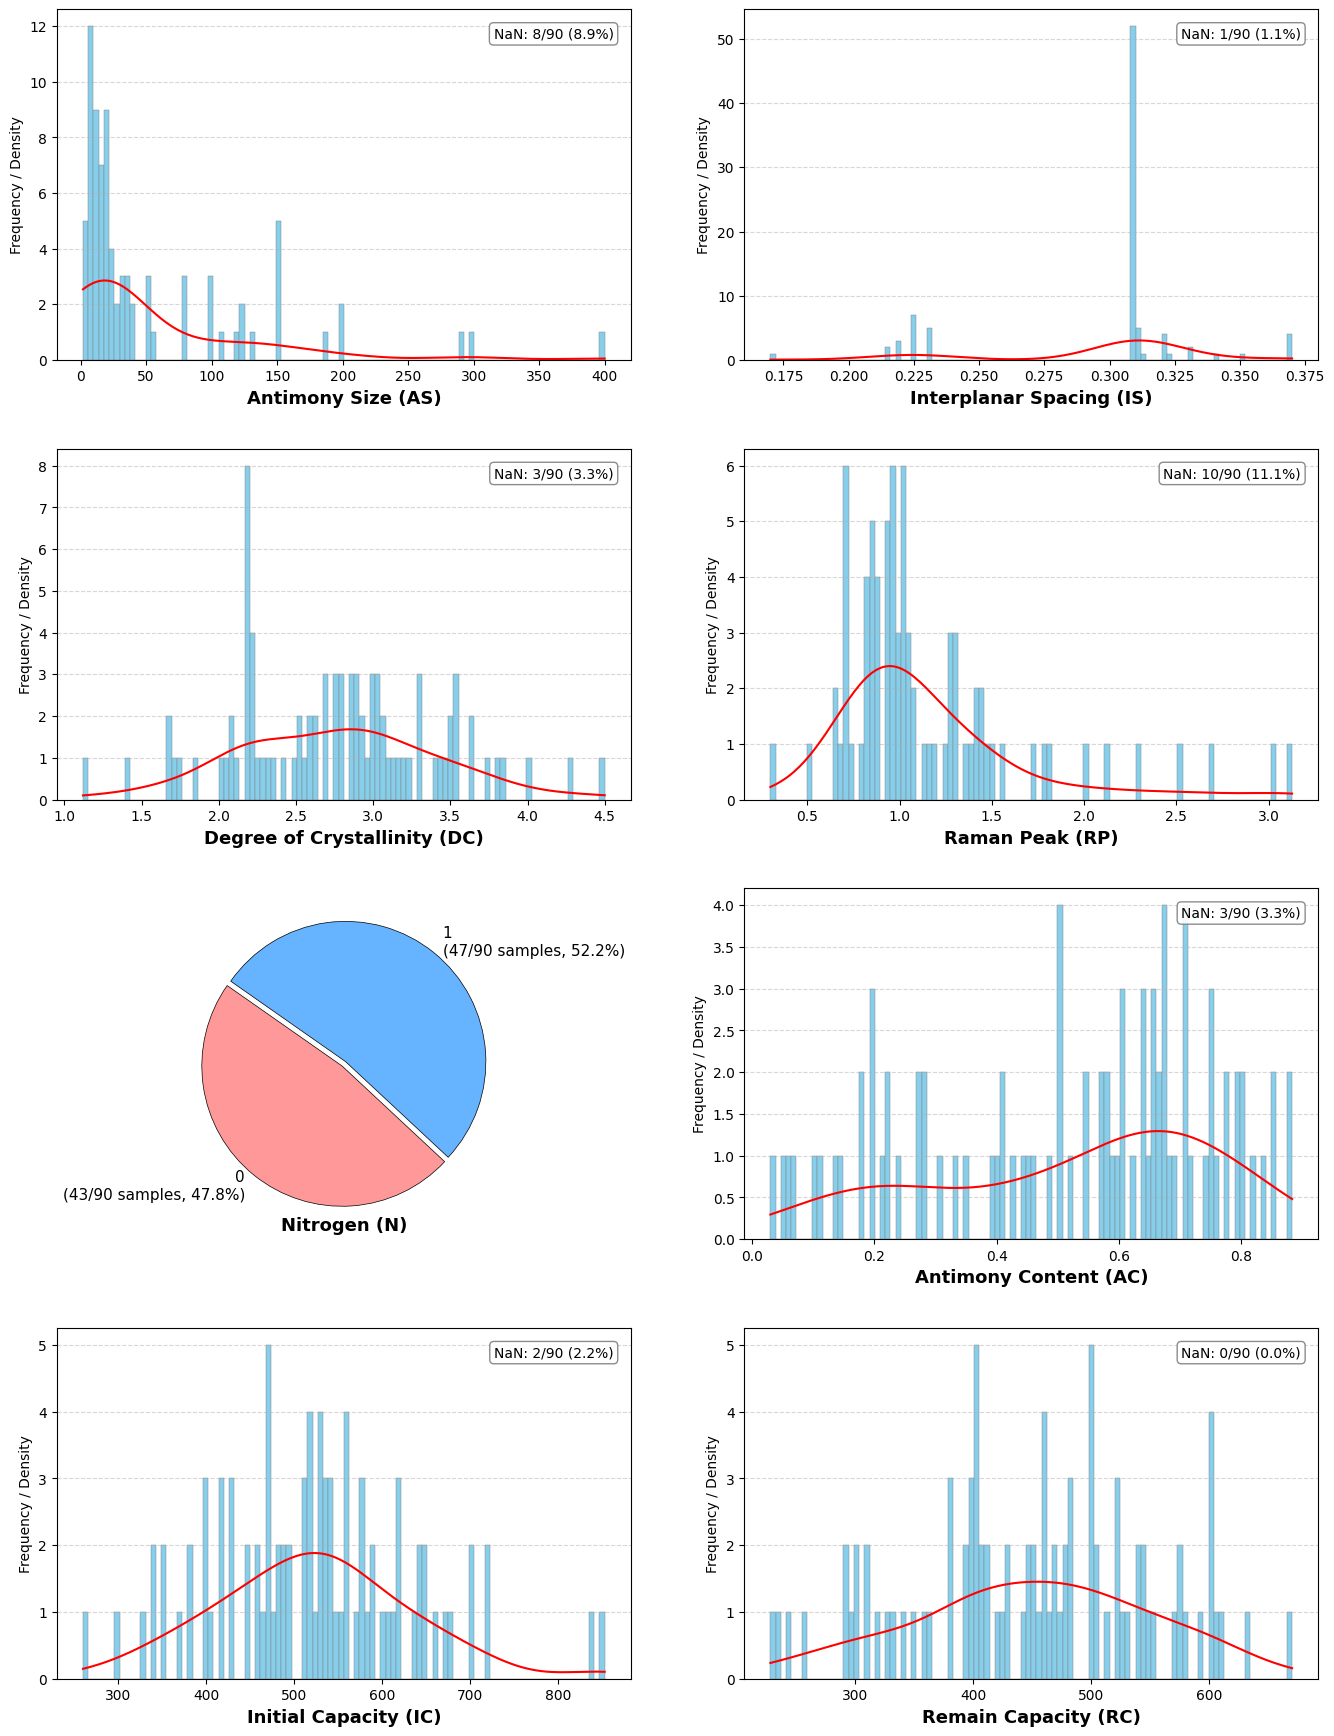

In [4]:
def visualize_distribution(series: pd.Series, ax=None):
    """
    Vẽ biểu đồ phân phối (histogram + KDE curve) cho một cột dữ liệu,
    kèm theo chú thích về tỉ lệ giá trị thiếu (NaN).

    Parameters:
    -----------
    series : pd.Series
        Cột dữ liệu cần quan sát.
    ax : matplotlib.axes.Axes, optional
        Trục vẽ (nếu muốn vẽ nhiều hình trên 1 subplot). Nếu None, sẽ tạo hình mới.
    """
    # Tạo figure nếu không có ax được truyền vào
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # 1. Lấy tên cột (để làm tiêu đề)
    col_name = full_name[series.name] + f' ({series.name})' if series.name else "Data"

    # 2. Tính toán thống kê NaN
    total_samples = len(series)
    nan_count = series.isna().sum()
    nan_percentage = (nan_count / total_samples) * 100

    # 3. Vẽ biểu đồ (loại bỏ NaN khi vẽ để tránh lỗi warning)
    data_clean = series.dropna()
    
    # Vẽ histogram (histplot) và đường cong mật độ (kde)
    sns.histplot(data_clean, ax=ax, 
                 facecolor='skyblue', edgecolor='gray', alpha=0.6,
                 kde=True,color='red',
                 bins=100)

    # 4. Tạo nội dung chú thích (Legend thông tin NaN)
    stats_text = (
        f"NaN: {nan_count}/{total_samples} ({nan_percentage:.1f}%)"
    )

    # 5. Thêm Text Box vào biểu đồ
    # bbox tạo khung viền xung quanh text, giống một legend
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    
    # Đặt vị trí text box ở góc trên bên phải (x=0.97, y=0.95 theo hệ trục tương đối)
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    # 6. Trang trí biểu đồ
    ax.set_xlabel(f'{col_name}', fontsize=13, weight='bold')
    ax.set_ylabel("Frequency / Density")
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    return ax

def visualize_categories_pie(series, ax=None, color_map={0: '#ff9999', 1: '#66b3ff'} ):
    """
    Vẽ biểu đồ tròn cho cột Categorical (ví dụ: Nitrogen), 
    hiển thị số lượng và tỉ lệ phần trăm của từng nhóm (bao gồm NaN).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # 1. Đếm giá trị (giữ lại NaN để vẽ) và sắp xếp theo index (0, 1, NaN)
    counts = series.value_counts(dropna=False).sort_index()
    
    # 2. Chuẩn bị dữ liệu hiển thị (Labels và Colors)
    total = len(series)
    labels = []
    colors = []
    
    # Định nghĩa màu: NaN (Xám), Default (xanh lá)
    nan_color = '#d3d3d3' 
    default_color = '#99ff99'

    for idx, count in counts.items():
        # Tính phần trăm
        pct = (count / total) * 100
        
        # Xử lý nhãn text và màu sắc
        if pd.isna(idx):
            label_text = "NaN"
            c = nan_color
        else:
            # Chuyển về int để hiển thị đẹp hơn (vd: 1.0 -> 1)
            label_text = str(int(idx)) 
            c = color_map.get(int(idx), default_color) # Màu mặc định nếu có nhãn lạ
        
        # Format label: Nhãn xuống dòng (Số lượng, %)
        labels.append(f"{label_text}\n({count}/{total} samples, {pct:.1f}%)")
        colors.append(c)

    # 3. Vẽ biểu đồ tròn
    ax.pie(counts, labels=labels, 
        colors=colors, autopct=None,
        startangle=145, 
        explode=[0.02] * len(counts) ,                      # Adds space between slices
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'black'}, # Adds the border
        textprops={'fontsize': 11, 'color': 'black'})

    # 4. Đặt tiêu đề
    col_name = f'{full_name[series.name]} ({series.name})' if series.name else "Data"
    ax.set_title(f'{col_name}', fontsize=13, weight='bold', y=0)
    
    return ax



# --- Ví dụ cách sử dụng  ---
# 1. Tạo khung hình lưới (Figure & Axes)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

# 2. Vòng lặp vẽ từng biểu đồ
for i, col_name in enumerate(data.columns):
    if col_name == 'N' :
        visualize_categories_pie(data[col_name], ax=axes[i])
    else :
        visualize_distribution(data[col_name], ax=axes[i])

# 3. Tinh chỉnh layout
plt.tight_layout(pad=3)
plt.show()

### 1.2.2. <a id='toc1_2_2_'></a>[Khảo sát mức tương quan tuyến tính (Correlation)](#toc0_)

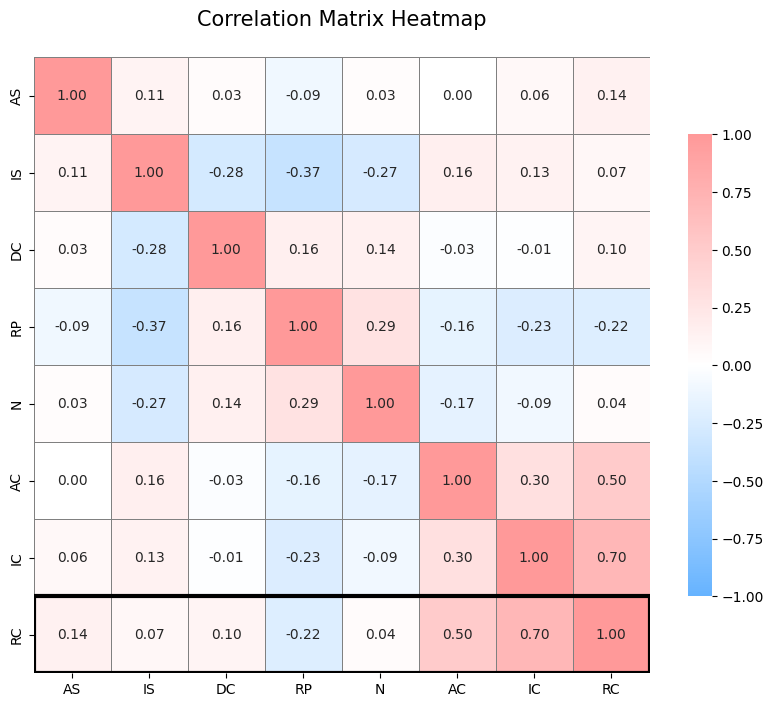

In [5]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

def draw_heatmap(df, ax=None):
    """
    Vẽ Heatmap ma trận tương quan cho tất cả các cột trong DataFrame.
    Sử dụng bảng màu tùy chỉnh với 2 màu chủ đạo: '#66b3ff' (Blue) và '#ff9999' (Red).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # 1. Tính ma trận tương quan (chỉ tính trên các cột số)
    corr_matrix = df.corr(numeric_only=True)

    # 2. Tạo bảng màu tùy chỉnh (Custom Colormap)
    # Gradient: Xanh (#66b3ff) -> Trắng (#ffffff) -> Đỏ (#ff9999)
    # Màu trắng ở giữa giúp dễ nhìn ra các biến không tương quan (gần 0)
    colors = ['#66b3ff', '#ffffff', '#ff9999']
    custom_cmap = LinearSegmentedColormap.from_list('custom_blue_red', colors, N=256)

    # Highlight the Remain Capacity (RC) row
    rect = patches.Rectangle(
        (0, len(data.columns)-1), 
        width=len(data.columns), 
        height=1, 
        linewidth=3, 
        edgecolor='black', 
        facecolor='none' # Must be none so the heatmap colors show through
    )

    # 3. Vẽ Heatmap
    sns.heatmap(
        corr_matrix, 
        annot=True,           # Hiển thị số liệu trong ô
        fmt=".2f",            # Định dạng số (2 chữ số thập phân)
        cmap=custom_cmap,     # Sử dụng bảng màu đã tạo
        vmin=-1, vmax=1,      # Cố định thang đo từ -1 đến 1
        center=0,             # Căn giữa màu trắng tại giá trị 0
        square=True,          # Ép các ô thành hình vuông
        linewidths=0.5,       # Đường viền giữa các ô
        linecolor='gray',
        cbar_kws={"shrink": 0.75}, # Thu nhỏ thanh chú thích màu một chút
        ax=ax
    )

    ax.add_patch(rect)

    # 4. Trang trí
    ax.set_title("Correlation Matrix Heatmap\n", fontsize=15)
    
    return ax


# --- Ví dụ cách sử dụng ---
draw_heatmap(data)
plt.show()

In [6]:
np.argmin(np.abs(data['IC'] / data['RC'] - 1))
data.iloc[85]

AS     20.00
IS      0.32
DC      2.93
RP      0.95
N       0.00
AC      0.78
IC    540.40
RC    540.50
Name: 85, dtype: float64

### 1.2.3. <a id='toc1_2_3_'></a>[Quan sát kỹ hơn tương quan tuyến tính](#toc0_)

In [7]:
from sklearn.cluster import KMeans

def visualize_correlation(feature, target, ax=None):
    """
    Vẽ biểu đồ tương quan (Scatter + Regression Line) giữa Feature và Target.
    Trục X: Target (RC)
    Trục Y: Feature
    Hiển thị thêm hệ số tương quan Pearson (r) và p-value.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # 1. Kết hợp dữ liệu và loại bỏ NaN để tính toán thống kê chính xác
    # (Tránh lỗi khi tính Pearson hoặc vẽ hồi quy)
    data = pd.DataFrame({'Target': target, 'Feature': feature}).dropna()
    
    # Nếu không còn dữ liệu sau khi dropna thì không vẽ
    if len(data) < 2:
        ax.text(0.5, 0.5, "Not enough data", ha='center', va='center')
        return ax

    # 2. Tính hệ số tương quan Pearson
    r, p = stats.pearsonr(data['Target'], data['Feature'])

    # 3. Vẽ biểu đồ Scatter kèm đường hồi quy (regplot)
    # scatter_kws: độ trong suốt của điểm
    # line_kws:  màu đường hồi quy
    sns.regplot(x='Target', y='Feature', data=data, ax=ax, 
                scatter_kws={'alpha': 0.6, 's': 30}, 
                line_kws={'color': 'red', 'linewidth': 2})

    # 4. Hiển thị thông số thống kê lên biểu đồ
    stats_text = f"$r = {r:.2f}$\n$p = {p:.2e}$"
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')

    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

    # 5. Trang trí
    x_name = f'{full_name[target.name]} ({target.name})' if target.name else "Target"
    y_name = f'{full_name[feature.name]} ({feature.name})' if feature.name else "Feature"
    
    
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name, weight='bold', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    return ax

def visualize_target_by_category(category, target, ax=None):
    """
    Vẽ biểu đồ phân phối của Target (RC), tô màu theo Category (Nitrogen).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # 1. Tạo DataFrame tạm để seaborn dễ xử lý hue
    # fillna cho category để hiển thị được cả nhóm NaN (nếu muốn)
    cat_name = f"{full_name[category.name]} ({category.name})" if category.name else "Category"
    target_name = f"{full_name[target.name]} ({target.name})" if target.name else "Target"
    
    df_temp = pd.DataFrame({
        target_name: target,
        cat_name: category.fillna('NaN') # Đổi NaN thành chuỗi "NaN" để hiện trong legend
    })

    # 2. Vẽ histplot với hue
    
    custom_palette = {0: '#ff9999', 1: '#66b3ff', 'NaN': 'gray'}

    # multiple="stack": Chồng các cột lên nhau (hoặc dùng "layer" để xếp lớp)
    sns.histplot(
        data=df_temp,
        x=target_name, 
        hue=cat_name, 
        multiple="stack", 
        kde=True,
        ax=ax,
        palette=custom_palette, 
        edgecolor=".3",
        linewidth=.5,
        bins=20
    )

    # 3. Trang trí
    ax.set_xlabel(f"{target_name} depend on {cat_name}", fontsize=13)
    ax.set_ylabel("Number", weight='bold', fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    return ax

def visualize_cep_method(feature, target, cluster=4):
    """
    Displays two side-by-side CEP method visualizations.
    Left chart: Feature on X-axis, Target on Y-axis.
    Right chart: Target on X-axis, Feature on Y-axis.
    """
    # 1. Prepare data
    df = pd.DataFrame({'Feature': feature, 'Target': target}).dropna()
    X_data = df[['Feature', 'Target']].values 
    
    if len(df) < cluster:
        raise ValueError("Not enough valid data points to form the requested number of clusters.")

    # 2. Perform K-Means Clustering (Clusters remain the same regardless of axis orientation)
    kmeans = KMeans(n_clusters=cluster, random_state=42)
    labels = kmeans.fit_predict(X_data)
    centroids = kmeans.cluster_centers_
    
    # 3. Figure Setup
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    feature_name = feature.name if hasattr(feature, 'name') else 'Feature'
    target_name = target.name if hasattr(target, 'name') else 'Target'

    # ==========================================
    # CHART 1: Feature on X-axis, Target on Y-axis
    # ==========================================
    # Sort centroids by Feature (X-axis)
    centroids_1 = centroids[centroids[:, 0].argsort()]
    cx_1, cy_1 = centroids_1[:, 0], centroids_1[:, 1]
    
    # Fit Curve: Target = f(Feature)
    poly_func_1 = np.poly1d(np.polyfit(cx_1, cy_1, deg=2))
    
    # Plot Data & Centroids
    ax1.scatter(df['Feature'], df['Target'], c=labels, cmap='viridis', alpha=0.6)
    ax1.scatter(cx_1, cy_1, color='red', marker='*', s=300, edgecolors='black')
    
    # Plot Curve
    x_line_1 = np.linspace(df['Feature'].min(), df['Feature'].max(), 200)
    ax1.plot(x_line_1, poly_func_1(x_line_1), color='red', linestyle='--', linewidth=2)
    
    ax1.set_title(f'Original: {target_name} = f({feature_name})')
    ax1.set_xlabel(feature_name)
    ax1.set_ylabel(target_name)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # ==========================================
    # CHART 2: Target on X-axis, Feature on Y-axis
    # ==========================================
    # Sort centroids by Target (New X-axis)
    centroids_2 = centroids[centroids[:, 1].argsort()]
    cx_2, cy_2 = centroids_2[:, 1], centroids_2[:, 0]
    
    # Fit Curve: Feature = f(Target)
    poly_func_2 = np.poly1d(np.polyfit(cx_2, cy_2, deg=2))
    
    # Plot Data & Centroids
    ax2.scatter(df['Target'], df['Feature'], c=labels, cmap='viridis', alpha=0.6)
    ax2.scatter(cx_2, cy_2, color='red', marker='*', s=300, edgecolors='black')
    
    # Plot Curve
    x_line_2 = np.linspace(df['Target'].min(), df['Target'].max(), 200)
    ax2.plot(x_line_2, poly_func_2(x_line_2), color='red', linestyle='--', linewidth=2)
    
    ax2.set_title(f'Swapped Axes: {feature_name} = f({target_name})')
    ax2.set_xlabel(target_name)
    ax2.set_ylabel(feature_name)
    ax2.grid(True, linestyle=':', alpha=0.7)

    # Finalize Layout
    plt.tight_layout()
    plt.show()
    
    # Return both functions in case you want to use the mathematical formulas later
    return poly_func_1, poly_func_2

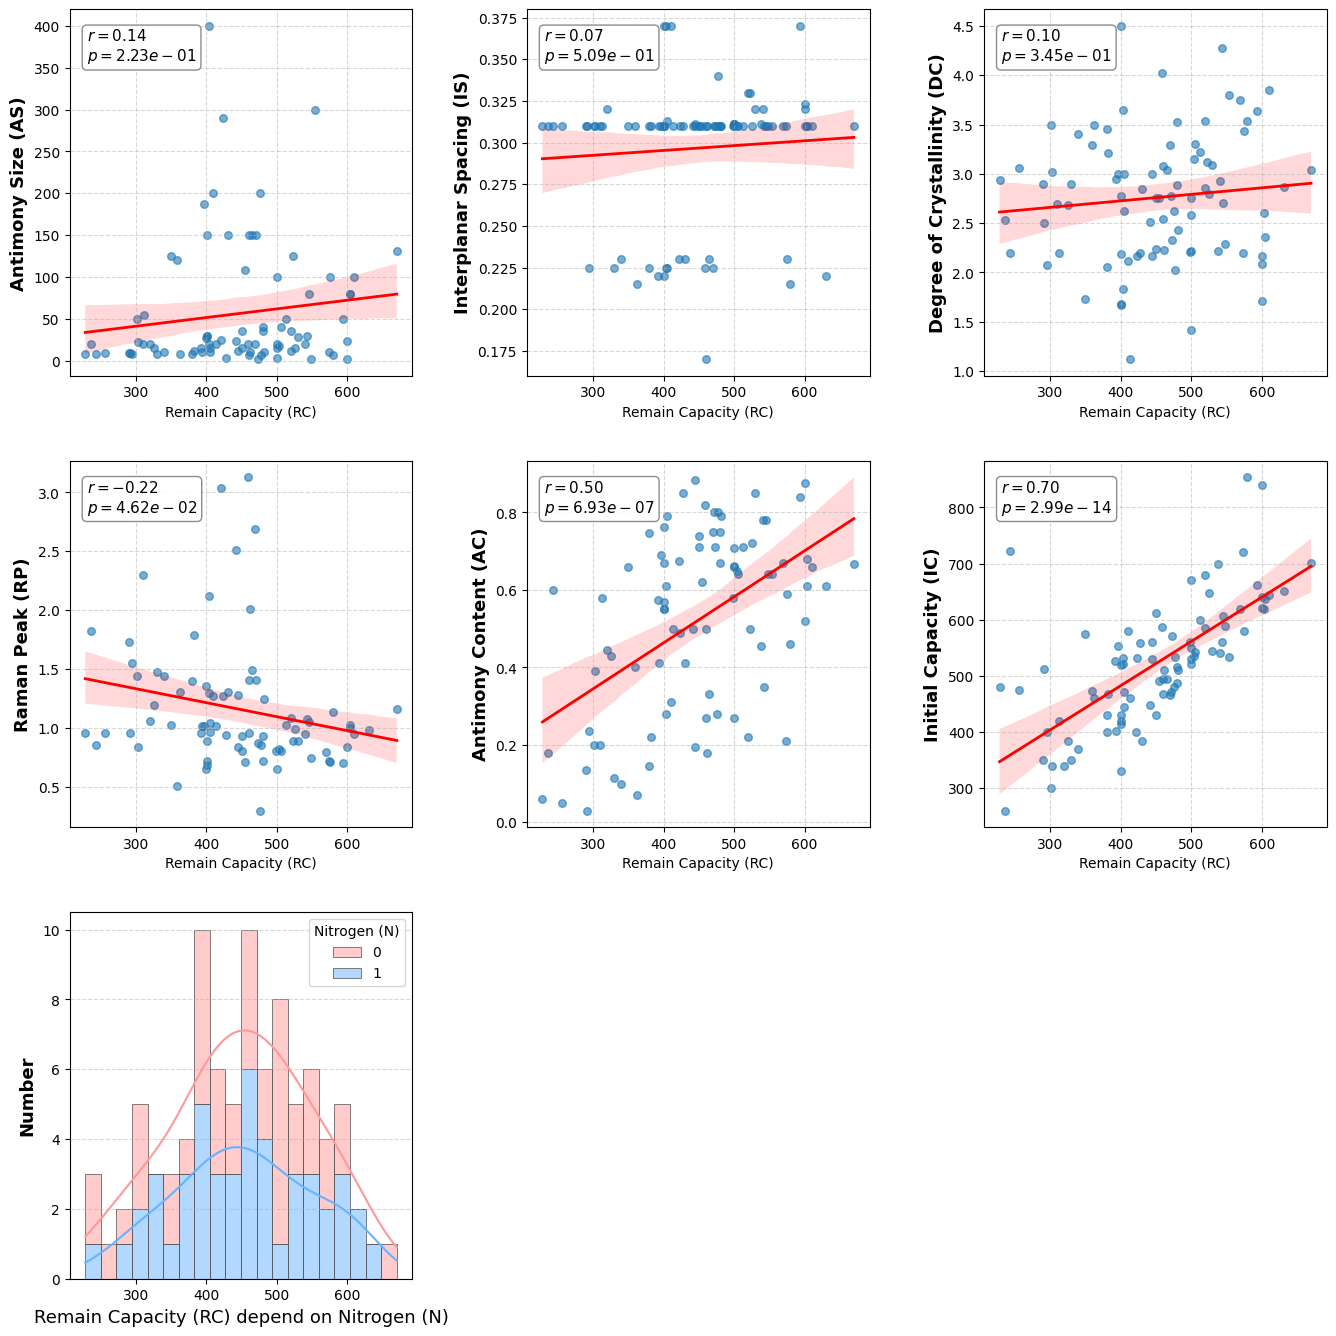

In [8]:

# --- Ví dụ cách sử dụng  ---
# 1. Tạo khung hình lưới (Figure & Axes)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 14))
axes = axes.flatten()
for i in range(7, 9): fig.delaxes(axes[i])  # Xóa 2 ax thừa

# 2. Vòng lặp vẽ từng biểu đồ
i = 0
visualize_target_by_category(category=data['N'], target=y, ax=axes[6])
for col_name in data.columns:
    if col_name not in [y.name, 'N'] :
        visualize_correlation(
            feature=data[col_name], 
            target=y, 
            ax=axes[i])
        i += 1


# 3. Tinh chỉnh layout
plt.tight_layout(pad=3)
plt.show()

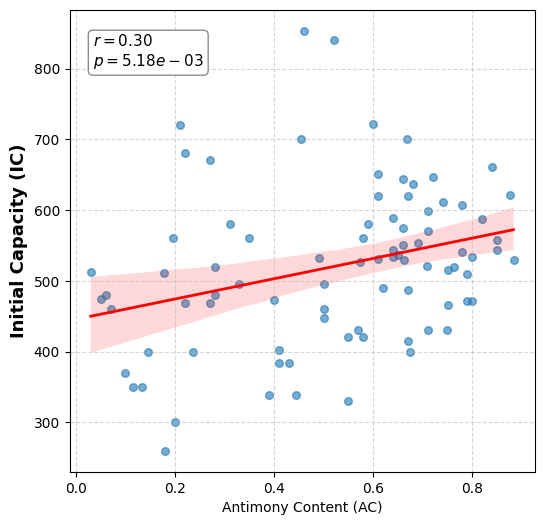

In [9]:
visualize_correlation(feature=data['IC'], target=data['AC'])
plt.show()

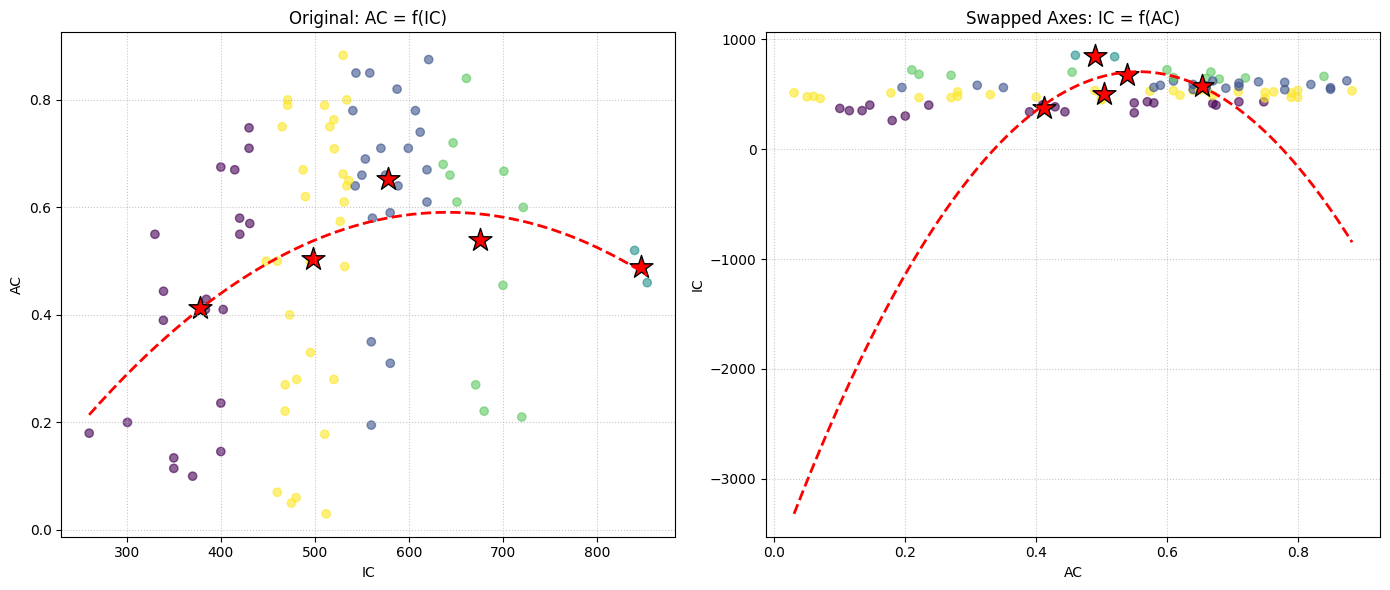

In [20]:
visualize_cep_method(feature=data['IC'], target=data['AC'], cluster=5)
plt.show()

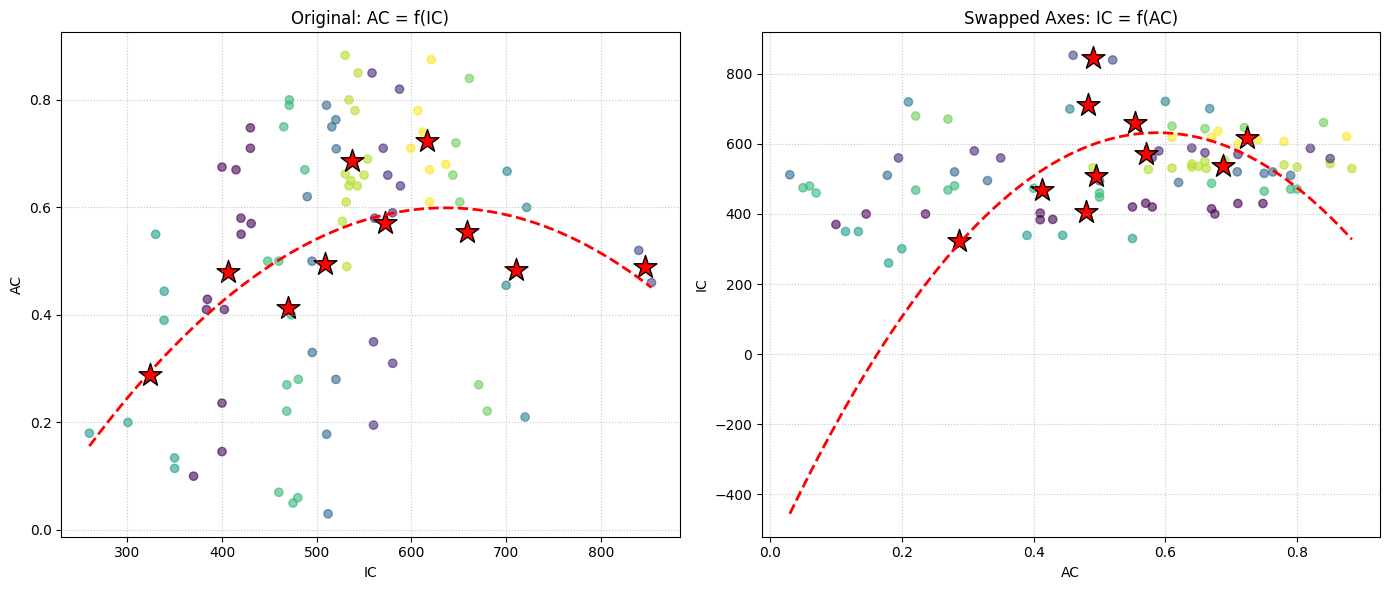

In [22]:
visualize_cep_method(feature=data['IC'], target=data['AC'], cluster=10)
plt.show()

# 2. <a id='toc2_'></a>[CHUẨN BỊ VÀ TIỀN XỬ LÝ](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Tiền xử lý](#toc0_)

Sử dụng:
- Phương pháp CEP 
    - Mục đích: để fillna một số cột quan trọng. 
    - *Note:* dataset hiện có đã được áp dụng sẵn phương pháp này rồi
- K-neighbors (để fillna)
    - Mục đích: để fillna (naive approach)
    - *Note:*
- Feature Engineering
    - Mục đích: khai thác thêm đặc trưng cho mô hình.
    - *Note:* Over-engineering. Dataset quá nhỏ, không phù hợp với tạo nhiều đặc trưng, bị nhiễu.

In [23]:
def feature_extraction_formulas(df_in):
    """
    Tạo các đặc trưng mới dựa trên công thức toán học được chỉ định.
    Bao gồm cả Feature cơ bản (Original) và Feature nâng cao (Physics-based).
    
    Parameters:
    - df_in: DataFrame gốc chứa các cột AC, AS, IS, DC, RP, N...
    
    Returns:
    - df_out: DataFrame đã bao gồm các feature mới với tên cột dạng công thức.
    """
    df_out = df_in.copy()
    
    # Hằng số nhỏ để tránh chia cho 0
    epsilon = 1e-6
    
    # Tạo biến phụ trợ (Helper) cho (1 - AC) để code gọn và dễ đọc hơn
    # (1 - AC) đại diện cho phần tỷ lệ khối lượng của Vỏ Carbon
    df_out['(1 - AC)'] = 1 - df_out['AC']

    # =========================================================================
    # NHÓM 1: CẤU TRÚC LÕI & ỨNG SUẤT (CORE STRUCTURE & STRESS)
    # =========================================================================
    
    # 1. AC * AS: Ứng suất thể tích tuyến tính
    df_out['AC * AS'] = df_out['AC'] * df_out['AS']
    
    # 2. AC * AS^3: Ứng suất thể tích thực (High-Order Volumetric Stress)
    # Hạt hình cầu, thể tích ~ r^3 -> Sức công phá tỷ lệ với AS^3
    df_out['AC * AS^3'] = df_out['AC'] * (df_out['AS'] ** 3)
    
    # 3. AC / (1 - AC): Tỷ lệ Lõi/Vỏ (Core-Shell Ratio)
    # Càng cao -> Vỏ càng mỏng so với lõi -> Rủi ro cao
    df_out['AC / (1 - AC)'] = df_out['AC'] / (df_out['(1 - AC)'] + epsilon)

    # =========================================================================
    # NHÓM 2: CẤU TRÚC VỎ & SỨC BỀN (SHELL STRUCTURE & STRENGTH)
    # =========================================================================
    
    # 4. DC * RP: Khả năng lưu trữ hoạt động (Active Storage)
    df_out['DC * RP'] = df_out['DC'] * df_out['RP']
    
    # 5. DC / RP: Độ giòn cấu trúc (Brittleness)
    df_out['DC / RP'] = df_out['DC'] / (df_out['RP'] + epsilon)
    
    # 6. (1 - AC) * DC: Sức bền vỏ Carbon (Shell Strength)
    # Vỏ bền cần cả độ dày (1-AC) và độ cứng (DC)
    df_out['(1 - AC) * DC'] = df_out['(1 - AC)'] * df_out['DC']
    
    # 7. (1 - AC) * RP / DC: Độ dẻo hiệu dụng của vỏ (Weighted Shell Elasticity)
    # Vỏ dày và có tính dẻo (RP/DC cao) giúp chịu lực tốt hơn
    df_out['(1 - AC) * RP / DC'] = df_out['(1 - AC)'] * (df_out['RP'] / (df_out['DC'] + epsilon))

    # =========================================================================
    # NHÓM 3: CƠ HỌC PHÁ HỦY (FRACTURE MECHANICS)
    # =========================================================================

    # 9. AC * AS * DC / RP: Rủi ro phá hủy cơ bản (Basic Failure Risk)
    # Sử dụng các cột đã tính ở trên
    df_out['AC * AS * DC / RP'] = df_out['AC * AS'] * df_out['DC / RP']
    
    # 10. (AC * AS^3) / ((1 - AC) * DC): Chỉ số phá hủy tới hạn (Critical Failure Index)
    # Tỷ lệ giữa Lực giãn nở thể tích (Mũ 3) và Sức bền vỏ
    # Đây là feature quan trọng nhất để bắt các ca "Vỡ vỏ" (Outliers)
    numerator = df_out['AC * AS^3']
    denominator = df_out['(1 - AC) * DC'] + epsilon
    df_out['(AC * AS^3) / ((1 - AC) * DC)'] = numerator / denominator

    # =========================================================================
    # NHÓM 4: ĐỘNG HỌC & TƯƠNG TÁC (KINETICS & INTERACTION)
    # =========================================================================

    # 11. AC * AS / IS: Mật độ ứng suất trên khe hở
    df_out['AC * AS / IS'] = df_out['AC * AS'] / (df_out['IS'] + epsilon)
    
    # 12. AC / IS: Mật độ vật liệu trên khe hở
    df_out['AC / IS'] = df_out['AC'] / (df_out['IS'] + epsilon)
    
    # 13. IS / AS: Chỉ số khuếch tán tuyến tính
    df_out['IS / AS'] = df_out['IS'] / (df_out['AS'] + epsilon)
    
    # 14. AS^2 / IS: Thời gian khuếch tán (Diffusion Time Constant)
    # Theo định luật Fick: t ~ L^2 / D (L là AS, D là IS)
    df_out['AS^2 / IS'] = (df_out['AS'] ** 2) / (df_out['IS'] + epsilon)
    
    # 15. AC / AS: Diện tích bề mặt tiếp xúc (Surface Exposure)
    # Tỷ lệ nghịch với kích thước hạt. Gây hao hụt do tạo SEI.
    df_out['AC / AS'] = df_out['AC'] / (df_out['AS'] + epsilon)
    
    return df_out


In [24]:
def apply_cep_method(df, feature_col, target_col, n_clusters=4):
    """
    Implements the CEP method generically for any two columns: 
    1. Finds valid data where both feature and target exist.
    2. Uses K-Means clustering to find trends.
    3. Fits a degree 2 polynomial curve to the clusters.
    4. Fulfills missing target values based on the feature values.
    
    Parameters:
    - df: DataFrame containing the data.
    - feature_col: String, the name of the independent variable column (e.g., 'AC').
    - target_col: String, the name of the column with missing values to predict (e.g., 'IC').
    - n_clusters: Int, the number of clusters to form (default is 4).
    """
    df_cep = df.copy()
    
    # 1. Isolate rows where both feature and target are NOT null
    valid_data = df_cep.dropna(subset=[feature_col, target_col])
    
    if len(valid_data) < n_clusters:
        raise ValueError(f"Not enough valid data points to form {n_clusters} clusters.")
    
    # 2. Apply K-Means Clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(valid_data[[feature_col, target_col]])
    
    # Get the center points and sort them by the feature (X-axis)
    centers = kmeans.cluster_centers_
    centers = centers[centers[:, 0].argsort()]
    
    # 3. Fit a curve (Degree 2 polynomial) through the cluster centers
    # X = feature_col (column 0), Y = target_col (column 1)
    poly_coeffs = np.polyfit(centers[:, 0], centers[:, 1], deg=2)
    trend_curve = np.poly1d(poly_coeffs)
    
    # 4. Fill missing target values using the fitted curve
    # Ensure we only try to fill if the target is missing AND the feature is actually present
    missing_target_mask = df_cep[target_col].isnull() & df_cep[feature_col].notnull()
    
    # Calculate new target values where missing, based on the row's feature value
    df_cep.loc[missing_target_mask, target_col] = trend_curve(df_cep.loc[missing_target_mask, feature_col])
    
    return df_cep

def force_apply_interpolation(df, feature_col, target_col):
    """
    Điền các giá trị NaN trong target_col bằng công thức nội suy cố định.
    
    Các hàng đã có giá trị ở target_col sẽ được giữ nguyên.
    Thao tác này sẽ chỉnh sửa trực tiếp (in-place) lên DataFrame.
    """
    mask = df[target_col].isnull() & df[feature_col].notnull()
    
    x = df.loc[mask, feature_col]
    
    # Tính toán y theo phương trình đa thức tại đây
    y_calc = -6230 * (x ** 2) + 7335 * x - 1485
    
    df.loc[mask, target_col] = y_calc
    
    return df


In [1]:
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer

def preprocessing_pipeline(X, y):
    """
    Chuỗi các bước tiền xử lý dữ liệu:
    1. Xử lý giá trị thiếu (NaN) bằng cách CEP và KNN Imputer.
    2. Feature Extraction (optional)
    
    Parameters:
    - X: DataFrame chưa được tạo feature (chỉ chứa các cột AC, AS, RP, IS, N, IC, DC)
    - y: Series chứa giá trị mục tiêu (Remain Capacity - RC)
    
    Returns:
    - X, y đã được xử lý sẵn sàng cho bước tiếp theo (ví dụ: train/test split, modeling)
    """
    
    # # 1. Dùng quy trình CEP để điền giá trị còn thiếu 
    # # --- IGNORE ---
    #X_cep = apply_cep_method(X, feature_col='AC', target_col='IC', n_clusters=15)
    X_cep = force_apply_interpolation(X, feature_col='AC', target_col='IC')

    # 2. Điền các giá trị NaN còn lại (nếu có) bằng KNN Imputer
    imputer = KNNImputer(n_neighbors=5)
    X_imputed = pd.DataFrame(imputer.fit_transform(X_cep), columns=X_cep.columns)
    
    # # 3. Feature Over-Engineering 
    # # --- IGNORE ---
    # X_engineered = feature_extraction_formulas(X_imputed)

    return X_imputed, y


In [26]:
processed_X, processed_y = preprocessing_pipeline(X, y)

processed_X.describe()

,AC,AS,RP,IS,N,IC,DC
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,0.522733,56.405044,1.155160,0.296647,0.522222,519.644460,2.755844
std,0.232358,71.938080,0.502399,0.040652,0.502304,114.359285,0.634425
min,0.030000,1.780000,0.300000,0.170000,0.000000,243.644739,1.120000
25%,0.335000,10.250000,0.862500,0.310000,0.000000,451.150000,2.222500
50%,0.585000,24.500000,1.008000,0.310000,1.000000,523.800000,2.769000
75%,0.704250,77.575000,1.307500,0.310000,1.000000,586.800000,3.112500
max,0.883000,400.000000,3.127000,0.370000,1.000000,853.400000,4.500000


## 2.2. <a id='toc2_2_'></a>[Chia train-test](#toc0_)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = \
      train_test_split( processed_X,
                        processed_y,
                        test_size=18/90, 
                        random_state=42 )

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train.describe()

,AC,AS,RP,IS,N,IC,DC
count,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,72.000000,7.200000e+01,7.200000e+01
mean,-2.590520e-16,4.934325e-17,1.727014e-16,-5.921189e-16,0.000000,-8.141636e-16,2.220446e-16
std,1.007018e+00,1.007018e+00,1.007018e+00,1.007018e+00,1.007018,1.007018e+00,1.007018e+00
min,-2.123017e+00,-7.697319e-01,-1.636418e+00,-2.947165e+00,-1.000000,-2.123629e+00,-2.515432e+00
25%,-8.991980e-01,-6.622350e-01,-5.832559e-01,3.418923e-01,-1.000000,-6.292656e-01,-8.149490e-01
50%,3.023698e-01,-4.196475e-01,-3.175933e-01,3.418923e-01,0.000000,-2.365589e-02,5.659667e-02
75%,8.108110e-01,3.185767e-01,3.035828e-01,3.418923e-01,1.000000,5.991546e-01,6.531213e-01
max,1.584042e+00,4.437986e+00,3.728068e+00,1.751489e+00,1.000000,3.158244e+00,2.721590e+00


## 2.3. <a id='toc2_3_'></a>[Chuẩn bị hàm chạy k-fold](#toc0_)

In [28]:
from sklearn.model_selection import KFold
import optuna
from sklearn.model_selection import cross_validate
from functools import partial
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# --- Hàm tính toán các chỉ số đánh giá ---
def calculate_metrics(y_true, y_pred):
    """
    Tính toán 3 chỉ số quan trọng theo bài báo: R2, RMSE, MAE.
    """
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# --- Hàm huấn luyện K-fold Cross Validation ---
def run_kfold_wrapper(X, y, k=10, model_trainer=None):
    """
    Hàm Wrapper thực hiện K-Fold Cross Validation.
    
    Parameters:
    - X, y: Dữ liệu huấn luyện (đã tách khỏi Test set).
    - k: Số lượng fold (mặc định 10 theo bài báo).
    - model_trainer: Callback function. 
          Input: (X_train_fold, y_train_fold)
          Output: Trained Model (đã fit).
          
    Returns:
    - models: List các model đã train qua từng fold.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    models = []
    
    # Lưu lịch sử để tính trung bình cuối cùng
    history = {
        'val_r2': [], 'val_rmse': [], 'val_mae': [],
        'train_r2': [] # Chỉ cần theo dõi R2 train để xem có overfit không
    }

    print(f"{'='*20} \nSTART K-FOLD (K={k}) \n{'='*20}")
    
    for fold_idx, (train_index, val_index) in enumerate(kf.split(X, y)):
        # 1. Chia dữ liệu cho fold hiện tại
        X_fold_train, X_fold_val = X.iloc[train_index], X.iloc[val_index]
        y_fold_train, y_fold_val = y.iloc[train_index], y.iloc[val_index]
        
        # 2. Gọi Callback để train model
        # Callback tự lo việc khởi tạo và fit model
        model = model_trainer(X_fold_train, y_fold_train)
        
        # 3. Dự đoán
        y_train_pred = model.predict(X_fold_train)
        y_val_pred = model.predict(X_fold_val)
        
        # 4. Đánh giá
        train_r2, _, _ = calculate_metrics(y_fold_train, y_train_pred)
        val_r2, val_rmse, val_mae = calculate_metrics(y_fold_val, y_val_pred)
        
        # Lưu lại chỉ số
        history['train_r2'].append(train_r2)
        history['val_r2'].append(val_r2)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        models.append(model)
        
        # 5. In kết quả từng fold
        print(f"[Fold {fold_idx+1:02d}] "
              f"Train R2: {train_r2:5.3f} | "
              f"Val R2: {val_r2:5.3f} | "
              f"Val RMSE: {val_rmse:3.1f} | "
              f"Val MAE: {val_mae:3.1f}")

    # Tổng kết
    print(f"\n{'-'*20} AVERAGE PERFORMANCE {'-'*20}")
    print(f"Average Val R2  : {np.mean(history['val_r2']):5.3f} (±{np.std(history['val_r2']):.3f})")
    print(f"Average Val RMSE: {np.mean(history['val_rmse']):4.2f}")
    print(f"Average Val MAE : {np.mean(history['val_mae']):4.2f}")
    print(f"{'='*60}")
    
    return models

# --- Hàm đánh giá trên tập Test với Ensemble Averaging ---
def evaluate_on_test_set(models, X_test, y_test, permutation_repeats=10, random_state=42):
    """
    Đánh giá mô hình trên tập Test và tính toán Permutation Feature Importance.
    
    Thay vì sử dụng feature_importances_ mặc định (Gini), hàm này sử dụng kỹ thuật
    Permutation để đo lường độ sụt giảm hiệu suất thực tế khi xáo trộn feature.
    
    Parameters:
    - models: List các model đã huấn luyện.
    - X_test, y_test: Dữ liệu Test.
    - permutation_repeats: Số lần xáo trộn mỗi feature để lấy trung bình (default=10).
    
    Returns:
    - df_predictions: DataFrame dự đoán (Actual, Pred_Model_i, Ensemble_Avg).
    - df_perm_importance: DataFrame chứa Permutation Importance của từng model và trung bình.
    """
    print(f"\n{'='*30} EVALUATION & PERMUTATION IMPORTANCE REPORT {'='*30}")
    
    # 1. CHUẨN BỊ
    df_preds = pd.DataFrame({'Actual': y_test.values}, index=y_test.index)
    metrics_list = []
    all_preds_array = []
    
    feature_names = X_test.columns.tolist() if hasattr(X_test, 'columns') else [f'Feat_{i}' for i in range(X_test.shape[1])]
    df_perm = pd.DataFrame(index=feature_names) # DataFrame lưu Permutation Importance

    # 2. DUYỆT QUA TỪNG MODEL
    for i, model in enumerate(models):
        col_name = f'Model_{i+1}'
        
        # A. Dự đoán & Metrics
        preds = model.predict(X_test)
        all_preds_array.append(preds)
        df_preds[col_name] = preds
        
        r2, rmse, mae = calculate_metrics(y_test, preds)
        metrics_list.append({'Model': col_name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})
        
        # B. Tính Permutation Importance (Thay thế feature_importances_ mặc định)
        # Đo lường sự sụt giảm R2 khi xáo trộn từng feature
        perm_result = permutation_importance(
            model, X_test, y_test,
            n_repeats=permutation_repeats,
            random_state=random_state,
            n_jobs=-1,
            scoring='r2' # Dùng R2 làm thước đo sụt giảm
        )
        
        # Lưu mean importance vào DataFrame
        df_perm[col_name] = perm_result.importances_mean

    # 3. ENSEMBLE RESULTS
    avg_preds = np.mean(all_preds_array, axis=0)
    df_preds['Ensemble_Avg'] = avg_preds
    
    ens_r2, ens_rmse, ens_mae = calculate_metrics(y_test, avg_preds)
    metrics_list.append({'Model': 'Ensemble_Avg', 'R2': ens_r2, 'RMSE': ens_rmse, 'MAE': ens_mae})

    # 4. TỔNG HỢP IMPORTANCE
    if not df_perm.empty:
        df_perm['Average_Importance'] = df_perm.mean(axis=1)
        df_perm = df_perm.sort_values(by='Average_Importance', ascending=False)

    # 5. IN KẾT QUẢ
    print("\n--- PERFORMANCE METRICS TABLE ---")
    print(pd.DataFrame(metrics_list).set_index('Model').round(4))
    
    print(f"\n{'='*80}")
    
    return df_preds, df_perm


## 2.4. <a id='toc2_4_'></a>[Optuna Tuning Wrapper](#toc0_)

In [29]:
# --- QUY TRÌNH TUNING VỚI OPTUNA ---
def run_optuna_tuning(X_train, y_train, search_ranges, objective_func, n_trials=50):
    """
    Hàm Wrapper để chạy quá trình tìm kiếm tham số tối ưu.
    """
    # Tạo study: hướng tới tối đa hóa final_score
    study = optuna.create_study(direction='maximize')
    
    # Sử dụng partial/lambda để truyền thêm tham số phụ vào hàm objective
    func = lambda trial: objective_func(trial, X_train, y_train, search_ranges)
    
    # Tắt log chi tiết của từng trial cho đỡ rối mắt (chỉ hiện thanh progress hoặc kết quả cuối)
    print(f"Bắt đầu Tuning Random Forest với {n_trials} lần thử...")
    optuna.logging.set_verbosity(optuna.logging.WARNING) 
    
    study.optimize(func, n_trials=n_trials, show_progress_bar=True)
    
    print("\n" + "="*30)
    print("KẾT QUẢ TỐI ƯU")
    print(f"Best Objective Score: {study.best_value:.4f}")
    print("Best Params found:")
    for key, value in study.best_params.items():
        print(f"  - {key}: {value}")
    print("="*30)
    
    return study.best_params


# 3. <a id='toc3_'></a>[HUẨN LUYỆN MODEL (!!!)](#toc0_)

## 3.1. <a id='toc3_1_'></a>[Random Forest - Test R2: 0.66](#toc0_)

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from functools import partial

# --- HÀM MỤC TIÊU CHO OPTUNA ---
def objective_rf(trial, X, y, search_ranges):
    """
    Hàm mục tiêu tùy chỉnh: Tối ưu hóa R2 Validation đồng thời giảm thiểu khoảng cách với Train.
    Score = Val_R2 - (Penalty * |Train_R2 - Val_R2|)
    """
    # 1. Gợi ý tham số từ vùng tìm kiếm (search_ranges)
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', *search_ranges['n_estimators']),
        'max_depth': trial.suggest_int('max_depth', *search_ranges['max_depth']),
        'min_samples_split': trial.suggest_int('min_samples_split', *search_ranges['min_samples_split']),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', *search_ranges['min_samples_leaf']),
        'max_features': trial.suggest_categorical('max_features', search_ranges['max_features']),
        'criterion': trial.suggest_categorical('criterion', search_ranges['criterion']),
        
        # Các tham số cố định
        'random_state': search_ranges['random_state'],
        'n_jobs': search_ranges['n_jobs']
    }
    
    # 2. Instantiate the model
    model = RandomForestRegressor(**rf_params)
    
    # 3. Setup K-Fold (Phase 3 update: k=10)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # 4. Calculate Validation R2
    # cross_val_score automatically handles the training/validation split for each fold
    # and returns the R2 score by default for regressors.
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    # 5. Return the average Validation R2
    return val_r2_scores.mean()


# --- QUY TRÌNH HUẤN LUYỆN 1 MODEL ---
def RandomForest_trainer(X_train, y_train, **kwargs):
    """
    Hàm khởi tạo và huấn luyện Random Forest.
    Nhận vào bất kỳ tham số nào của RF thông qua **kwargs.
    """
    # Khởi tạo model với các tham số được truyền vào
    # Nếu không truyền gì, nó sẽ dùng mặc định của Sklearn
    model = RandomForestRegressor(**kwargs)
    
    # Huấn luyện model
    model.fit(X_train, y_train)
    
    return model


In [31]:
# --- CẤU HÌNH THAM SỐ (Tuning) ở đây ---
rf_search_range = {
    'n_estimators': (150, 1000),             # Số lượng cây
    'max_depth': (5, 8),                   # Độ sâu tối đa của cây (để tránh overfit)
    'min_samples_split': (3, 20),           # Số mẫu tối thiểu để tách nút
    'min_samples_leaf': (3, 20),            # Số mẫu tối thiểu tại lá
    'max_features': [None, "sqrt", "log2"],                 # Số lượng đặc trưng được xem xét tại mỗi lần tách nút
    'criterion': ['squared_error', 'absolute_error'], # Hàm mất mát
    'random_state': 42,                     # Cố định random seed để tái lập kết quả
    'n_jobs': -1                            # Dùng tất cả nhân CPU để chạy nhanh hơn
}

# --- CẤU HÌNH TRỌNG SỐ ĐÁNH GIÁ ---
OVERFIT_PENALTY = 0.3                       # Hệ số phạt cho việc Overfitting: Result + PENALTY * Gap(train-val)

# --- CÁCH SỬ DỤNG ---
# 1. Tuning để tìm best params
best_rf_params = run_optuna_tuning(
    X_train, y_train, 
    rf_search_range, 
    objective_rf, 
    n_trials=50
)

# 2. Chạy model với best params đã tìm được
best_rf_params['random_state'] = 42
best_rf_params['n_jobs'] = -1
tuned_rf_trainer = partial(RandomForest_trainer, **best_rf_params)


rf_models_tuned = run_kfold_wrapper(
    X_train, y_train, 
    k=10, 
    model_trainer=tuned_rf_trainer
)

Bắt đầu Tuning Random Forest với 50 lần thử...


Best trial: 38. Best value: 0.235866: 100%|██████████| 50/50 [03:30<00:00,  4.20s/it] 



KẾT QUẢ TỐI ƯU
Best Objective Score: 0.2359
Best Params found:
  - n_estimators: 540
  - max_depth: 6
  - min_samples_split: 6
  - min_samples_leaf: 5
  - max_features: None
  - criterion: absolute_error
START K-FOLD (K=10) 
[Fold 01] Train R2: 0.660 | Val R2: 0.609 | Val RMSE: 56.6 | Val MAE: 49.2
[Fold 02] Train R2: 0.658 | Val R2: 0.139 | Val RMSE: 48.4 | Val MAE: 37.7
[Fold 03] Train R2: 0.642 | Val R2: 0.735 | Val RMSE: 38.1 | Val MAE: 33.3
[Fold 04] Train R2: 0.656 | Val R2: 0.473 | Val RMSE: 59.0 | Val MAE: 38.0
[Fold 05] Train R2: 0.638 | Val R2: -0.027 | Val RMSE: 77.1 | Val MAE: 68.7
[Fold 06] Train R2: 0.655 | Val R2: 0.454 | Val RMSE: 44.9 | Val MAE: 42.0
[Fold 07] Train R2: 0.651 | Val R2: 0.470 | Val RMSE: 55.4 | Val MAE: 49.8
[Fold 08] Train R2: 0.595 | Val R2: 0.235 | Val RMSE: 63.3 | Val MAE: 46.7
[Fold 09] Train R2: 0.794 | Val R2: -0.844 | Val RMSE: 146.0 | Val MAE: 106.9
[Fold 10] Train R2: 0.677 | Val R2: 0.114 | Val RMSE: 51.8 | Val MAE: 40.5

-------------------

** Nhận xét:

- PERMUTATION IMPORTANCE cho biết mức độ ảnh hưởng của một feature tới tổng thể kết quả cuối cùng.

- Trong khi IC có mức quan trọng tới 50%, thì phần còn lại chỉ loanh quanh 0 (tức là phần còn lại bị coi là nhiễu). Model thực sự không học được bất kỳ thứ gì, thay vào đó dự đoán vu vơ dựa trên IC.

In [32]:
rf_preds_df, rf_feature_importance_df = evaluate_on_test_set(
    rf_models_tuned, 
    X_test, y_test
)

rf_feature_importance_df.head()


============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2     RMSE      MAE
Model                                 
Model_1       0.6793  65.9557  58.4858
Model_2       0.7058  63.1779  55.1910
Model_3       0.6796  65.9314  57.0262
Model_4       0.7052  63.2456  53.8935
Model_5       0.6086  72.8717  65.1242
Model_6       0.6831  65.5733  57.9840
Model_7       0.6915  64.6896  56.2948
Model_8       0.6342  70.4487  60.1204
Model_9       0.6780  66.0981  56.0073
Model_10      0.6783  66.0668  57.5792
Ensemble_Avg  0.6820  65.6789  57.0888



,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Average_Importance
IC,0.848853,0.951968,0.956304,0.962075,0.742961,0.951262,0.868002,0.941295,0.970156,0.941724,0.913460
AC,0.134566,0.104682,0.084309,0.108120,0.103481,0.070990,0.147551,0.066973,0.101030,0.102555,0.102426
AS,0.004438,0.004675,0.004143,0.006426,0.002985,0.006916,0.008379,0.006616,0.003731,0.005976,0.005429
RP,0.003073,0.001318,0.003621,0.004753,0.004546,0.001379,0.003813,0.001609,0.002788,0.002759,0.002966
N,0.000232,0.001397,0.000121,-0.001087,-0.000849,0.000824,-0.001464,0.000057,-0.000416,0.002651,0.000147


## 3.2. <a id='toc3_2_'></a>[XGBoost - Test R2: 0.5](#toc0_)

In [33]:
import xgboost as xgb

# --- HÀM MỤC TIÊU CHO OPTUNA (XGBOOST) ---
def objective_xgb(trial, X, y, search_ranges):
    """
    Hàm mục tiêu cho XGBoost: Tối ưu hóa R2 Validation đồng thời giảm thiểu Overfitting.
    Score = Val_R2 + Train_R2 - (Penalty * |Train_R2 - Val_R2|)
    """
    
    # 1. Gợi ý tham số từ vùng tìm kiếm (search_ranges)
    params = {
        # --- Kiến trúc cây (Boosting) ---
        'n_estimators': trial.suggest_int('n_estimators', *search_ranges['n_estimators']),
        'learning_rate': trial.suggest_float('learning_rate', *search_ranges['learning_rate'], log=True),
        'max_depth': trial.suggest_int('max_depth', *search_ranges['max_depth']),
        
        # --- Stochastic Sampling (Chống Overfit) ---
        'subsample': trial.suggest_float('subsample', *search_ranges['subsample']),
        'colsample_bytree': trial.suggest_float('colsample_bytree', *search_ranges['colsample_bytree']),
        
        # --- Regularization (L1/L2) ---
        'reg_alpha': trial.suggest_float('reg_alpha', *search_ranges['reg_alpha']),   # L1
        'reg_lambda': trial.suggest_float('reg_lambda', *search_ranges['reg_lambda']), # L2
        
        # --- Loss Function ---
        # reg:squarederror (MSE) hoặc reg:absoluteerror (MAE - tốt cho outlier)
        'objective': trial.suggest_categorical('objective', search_ranges['objective']),
        
        # --- Tham số cố định ---
        'random_state': search_ranges['random_state'],
        'n_jobs': search_ranges['n_jobs']
    }
    
    # 2. Khởi tạo model XGBRegressor
    model = xgb.XGBRegressor(**params)
    
    # 3. Thực hiện Cross-Validation (K-Fold=7)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # 4. Calculate Validation R2
    # cross_val_score automatically handles the training/validation split for each fold
    # and returns the R2 score by default for regressors.
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    # 5. Return the average Validation R2
    return val_r2_scores.mean()

# --- QUY TRÌNH HUẤN LUYỆN 1 MODEL ---
def XGBoost_trainer(X_train, y_train, **kwargs):
    """
    Wrapper khởi tạo và huấn luyện XGBoost Regressor
    """
    model = xgb.XGBRegressor(**kwargs)
    model.fit(X_train, y_train)
    return model


In [34]:
# --- CẤU HÌNH THAM SỐ (Tuning) ở đây ---
xgb_search_range = {
    'n_estimators': (50, 1000),         # Số lượng cây
    'learning_rate': (0.01, 0.3),      # Tốc độ học (log scale)
    'max_depth': (3, 10),              # Độ sâu (nên giữ thấp <10 với data nhỏ)
    'subsample': (0.5, 1.0),           # Lấy mẫu dòng
    'colsample_bytree': (0.5, 1.0),    # Lấy mẫu cột
    'reg_alpha': (0.0, 3.0),          # L1 Regularization (phạt các trọng số không cần thiết về 0)
    'reg_lambda': (0.0, 3.0),         # L2 Regularization (phạt các trọng số lớn)
    'objective': ['reg:squarederror', 'reg:absoluteerror'], # Loss function
    'random_state': 42,
    'n_jobs': 1
}

# --- CẤU HÌNH TRỌNG SỐ ĐÁNH GIÁ ---
OVERFIT_PENALTY = 1                       # Hệ số phạt cho việc Overfitting: Result + PENALTY * Gap(train-val)


# --- CÁCH SỬ DỤNG ---
# 1. Tuning để tìm best params
best_xgb_params = run_optuna_tuning(
    X_train, y_train, 
    xgb_search_range, 
    objective_xgb, 
    n_trials=50
)

# 2. Sau khi có best params, cập nhật lại vào model trainer để chạy đánh giá chi tiết
best_xgb_params['random_state'] = 42
best_xgb_params['n_jobs'] = -1
tuned_xgb_trainer = partial(XGBoost_trainer, **best_xgb_params)


xgb_models_tuned = run_kfold_wrapper(
    X_train, y_train, 
    k=10, 
    model_trainer=tuned_xgb_trainer
)

Bắt đầu Tuning Random Forest với 50 lần thử...


Best trial: 24. Best value: 0.155761: 100%|██████████| 50/50 [00:24<00:00,  2.03it/s]



KẾT QUẢ TỐI ƯU
Best Objective Score: 0.1558
Best Params found:
  - n_estimators: 158
  - learning_rate: 0.04499330932562006
  - max_depth: 9
  - subsample: 0.8310633454494075
  - colsample_bytree: 0.6584081647427429
  - reg_alpha: 2.7408573647962426
  - reg_lambda: 2.6914657589413036
  - objective: reg:absoluteerror
START K-FOLD (K=10) 
[Fold 01] Train R2: 0.941 | Val R2: 0.435 | Val RMSE: 68.1 | Val MAE: 59.3
[Fold 02] Train R2: 0.946 | Val R2: 0.764 | Val RMSE: 25.4 | Val MAE: 21.8
[Fold 03] Train R2: 0.947 | Val R2: 0.624 | Val RMSE: 45.4 | Val MAE: 34.9
[Fold 04] Train R2: 0.968 | Val R2: -0.444 | Val RMSE: 97.6 | Val MAE: 67.6
[Fold 05] Train R2: 0.937 | Val R2: -0.757 | Val RMSE: 100.8 | Val MAE: 90.3
[Fold 06] Train R2: 0.949 | Val R2: 0.625 | Val RMSE: 37.2 | Val MAE: 30.8
[Fold 07] Train R2: 0.942 | Val R2: 0.501 | Val RMSE: 53.8 | Val MAE: 47.8
[Fold 08] Train R2: 0.933 | Val R2: 0.583 | Val RMSE: 46.7 | Val MAE: 39.8
[Fold 09] Train R2: 0.955 | Val R2: -0.482 | Val RMSE: 13

In [35]:
xgb_preds_df, xgb_feature_importance_df = evaluate_on_test_set(
    xgb_models_tuned, 
    X_test, y_test
)

xgb_feature_importance_df


============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2     RMSE      MAE
Model                                 
Model_1       0.4676  84.9898  68.2214
Model_2       0.5190  80.7772  65.0703
Model_3       0.5036  82.0607  64.5752
Model_4       0.3954  90.5682  68.0810
Model_5       0.4608  85.5284  71.7855
Model_6       0.5174  80.9167  66.1319
Model_7       0.4950  82.7704  68.1163
Model_8       0.5045  81.9909  66.2491
Model_9       0.6615  67.7615  58.0216
Model_10      0.4450  86.7703  70.7447
Ensemble_Avg  0.5180  80.8619  65.8582



,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Average_Importance
IC,0.427735,0.510497,0.533294,0.364206,0.392737,0.505389,0.493190,0.470419,0.617909,0.465038,0.478042
AC,0.071612,0.101703,0.091365,0.116740,0.139419,0.174119,0.112937,0.146693,0.148745,0.143070,0.124640
AS,0.037973,0.030912,0.025437,0.017426,0.048229,0.026497,0.011589,0.059463,0.015594,0.011792,0.028491
RP,0.037636,0.038513,-0.000290,0.004491,0.063003,0.036210,-0.013018,-0.003237,0.051853,0.001755,0.021691
IS,0.024760,0.036508,0.019249,0.014854,0.006606,0.010097,0.007936,0.018926,0.011823,0.023901,0.017466
N,0.026326,0.020472,0.016221,0.005686,0.013484,0.020067,0.007712,0.014005,0.000354,0.003140,0.012747
DC,-0.101152,-0.069209,-0.074247,-0.101341,-0.068460,-0.053900,-0.074960,-0.060700,0.012929,-0.099324,-0.069036


## 3.3. <a id='toc3_3_'></a>[SVR (Support Vector) - Test R2: 0.68](#toc0_)

In [36]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# --- HÀM MỤC TIÊU CHO OPTUNA (SVR) ---
def objective_svr(trial, X, y, search_ranges):
    """
    Hàm mục tiêu cho SVR: Tối ưu hóa R2 Validation trung bình.
    """
    
    # 1. Gợi ý tham số từ vùng tìm kiếm
    params = {
        'kernel': trial.suggest_categorical('kernel', search_ranges['kernel']),
        # Sử dụng log scale cho C vì vùng tìm kiếm trải rộng từ rất nhỏ đến rất lớn
        'C': trial.suggest_float('C', *search_ranges['C'], log=True),
        'gamma': trial.suggest_categorical('gamma', search_ranges['gamma']),
        'epsilon': trial.suggest_float('epsilon', *search_ranges['epsilon'], log=True)
    }
    
    # (Tùy chọn nâng cao) Nếu kernel là 'poly', Optuna có thể dò thêm bậc của đa thức (degree)
    if params['kernel'] == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)
        
    # 2. Khởi tạo model SVR
    model = SVR(**params)
    
    # 3. Thực hiện Cross-Validation (K-Fold=10)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # 4. Tính toán Validation R2
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    # 5. Trả về Validation R2 trung bình để Optuna tối đa hóa
    return val_r2_scores.mean()

# --- QUY TRÌNH HUẤN LUYỆN 1 MODEL ---
def SVR_trainer(X_train, y_train, **kwargs):
    """
    Wrapper khởi tạo và huấn luyện model SVR.
    """
    model = SVR(**kwargs)
    
    model.fit(X_train, y_train)
    return model


In [37]:
# --- CẤU HÌNH THAM SỐ (Tuning) ở đây ---
svr_search_range = {
    'kernel': ['rbf', 'linear', 'poly'],      # Các loại kernel phổ biến
    'C': (0.1, 1000.0),                       # Tham số phạt (C lớn: dễ overfit, C nhỏ: tổng quát tốt)
    'gamma': ['scale', 'auto'],               # Hệ số Kernel
    'epsilon': (0.01, 1.0)                    # Bán kính ống (tube) bỏ qua sai số
}

best_svr_params = run_optuna_tuning(
    X_train, y_train, 
    svr_search_range, 
    objective_svr, 
    n_trials=50
)


# --- TẠO HÀM TRAINER ĐÃ GẮN THAM SỐ ---
SVR_with_params = partial(SVR_trainer, **best_svr_params)

# --- CHẠY K-FOLD ---
svr_models_tuned = run_kfold_wrapper(
    X=X_train, 
    y=y_train, 
    k=10, 
    model_trainer=SVR_with_params
)

Bắt đầu Tuning Random Forest với 50 lần thử...


Best trial: 43. Best value: 0.246908: 100%|██████████| 50/50 [00:01<00:00, 27.62it/s]



KẾT QUẢ TỐI ƯU
Best Objective Score: 0.2469
Best Params found:
  - kernel: linear
  - C: 454.1094379249728
  - gamma: auto
  - epsilon: 0.03025760964095608
START K-FOLD (K=10) 
[Fold 01] Train R2: 0.493 | Val R2: 0.668 | Val RMSE: 52.2 | Val MAE: 45.1
[Fold 02] Train R2: 0.486 | Val R2: 0.534 | Val RMSE: 35.6 | Val MAE: 28.6
[Fold 03] Train R2: 0.485 | Val R2: 0.674 | Val RMSE: 42.2 | Val MAE: 36.7
[Fold 04] Train R2: 0.509 | Val R2: -0.294 | Val RMSE: 92.4 | Val MAE: 71.5
[Fold 05] Train R2: 0.446 | Val R2: 0.293 | Val RMSE: 64.0 | Val MAE: 59.2
[Fold 06] Train R2: 0.471 | Val R2: 0.818 | Val RMSE: 25.9 | Val MAE: 20.2
[Fold 07] Train R2: 0.472 | Val R2: 0.715 | Val RMSE: 40.6 | Val MAE: 33.0
[Fold 08] Train R2: 0.450 | Val R2: -0.014 | Val RMSE: 72.8 | Val MAE: 57.6
[Fold 09] Train R2: 0.673 | Val R2: -1.011 | Val RMSE: 152.5 | Val MAE: 104.9
[Fold 10] Train R2: 0.517 | Val R2: 0.086 | Val RMSE: 52.6 | Val MAE: 39.9

-------------------- AVERAGE PERFORMANCE --------------------
Aver

In [38]:
svr_preds_df, svr_feature_importance_df = evaluate_on_test_set(
    svr_models_tuned, 
    X_test, y_test
)

svr_feature_importance_df


============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2     RMSE      MAE
Model                                 
Model_1       0.7053  63.2311  52.1551
Model_2       0.6823  65.6534  52.0031
Model_3       0.6876  65.1027  53.2177
Model_4       0.6475  69.1572  54.5000
Model_5       0.7018  63.6095  53.8672
Model_6       0.6698  66.9299  56.2963
Model_7       0.6821  65.6763  54.6817
Model_8       0.6674  67.1695  55.3570
Model_9       0.6810  65.7821  53.5329
Model_10      0.6959  64.2288  54.3003
Ensemble_Avg  0.6871  65.1555  53.8932



,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Average_Importance
IC,0.815719,0.865753,0.948020,1.045361,0.820338,1.001136,0.996146,0.884790,0.945142,0.984158,0.930656
AC,0.233228,0.217887,0.142577,0.170279,0.240373,0.160939,0.188968,0.204641,0.206752,0.185263,0.195091
DC,0.020307,0.029617,0.012381,0.016867,0.003150,0.002748,0.007718,0.019819,0.022418,0.005028,0.014005
AS,-0.005358,-0.012983,-0.010504,-0.004109,-0.002961,-0.007930,-0.001349,-0.002345,-0.003014,-0.002865,-0.005342
IS,-0.009373,-0.007863,-0.005479,-0.009568,-0.008228,-0.007419,-0.008785,-0.011631,-0.009450,-0.007459,-0.008526
N,0.005851,-0.009034,0.019238,-0.007917,-0.007379,-0.018306,-0.021338,-0.019763,-0.024485,-0.011286,-0.009442
RP,-0.012817,-0.014025,-0.017753,-0.022617,-0.006697,-0.004893,-0.007705,-0.008406,-0.010584,-0.005249,-0.011075


## 3.4. <a id='toc3_4_'></a>[AdaBoost - Test R2: 0.64](#toc0_)

In [39]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# --- HÀM MỤC TIÊU CHO OPTUNA (ADABOOST) ---
def objective_ada(trial, X, y, search_ranges):
    """
    Hàm mục tiêu cho AdaBoost: Tối ưu hóa R2 Validation trung bình.
    """
    
    # 1. Gợi ý tham số cho Base Estimator (Decision Tree)
    base_max_depth = trial.suggest_int('max_depth', *search_ranges['max_depth'])
    
    # 2. Gợi ý tham số cho AdaBoost
    params = {
        'n_estimators': trial.suggest_int('n_estimators', *search_ranges['n_estimators']),
        'learning_rate': trial.suggest_float('learning_rate', *search_ranges['learning_rate'], log=True),
        'loss': trial.suggest_categorical('loss', search_ranges['loss']),
        'random_state': search_ranges['random_state']
    }
    
    # 3. Khởi tạo Base Estimator và Model AdaBoost
    # Lưu ý: Từ Scikit-Learn 1.2 trở đi, tham số 'base_estimator' được đổi tên thành 'estimator'
    base_tree = DecisionTreeRegressor(max_depth=base_max_depth, random_state=42)
    model = AdaBoostRegressor(estimator=base_tree, **params)
    
    # 4. Thực hiện Cross-Validation (K-Fold=10)
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    # 5. Tính toán Validation R2
    val_r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    
    # 6. Trả về Validation R2 trung bình để Optuna tối đa hóa
    return val_r2_scores.mean()

# --- QUY TRÌNH HUẤN LUYỆN 1 MODEL ---
def AdaBoost_trainer(X_train, y_train, **kwargs):
    """
    Wrapper khởi tạo và huấn luyện AdaBoost Regressor.
    Mặc định sử dụng DecisionTreeRegressor(max_depth=3).
    """

    base_tree = DecisionTreeRegressor(max_depth=kwargs.get('max_depth'), random_state=42)
    kwargs.pop('max_depth', None)  # Loại bỏ max_depth khỏi kwargs để tránh lỗi khi khởi tạo AdaBoost
    model = AdaBoostRegressor(estimator=base_tree, **kwargs)
    model.fit(X_train, y_train)
    return model

In [40]:
# --- CẤU HÌNH THAM SỐ (Tuning) ở đây ---
ada_search_range = {
    'max_depth': (3, 10),                     # Độ sâu của cây cơ sở (Base Estimator)
    'n_estimators': (50, 500),                # Số lượng vòng lặp boosting
    'learning_rate': (0.01, 2.0),             # Tốc độ học (log scale)
    'loss': ['linear', 'square', 'exponential'], # Hàm mất mát cập nhật trọng số
    'random_state': 42
}

best_ada_params = run_optuna_tuning(X_train, y_train, ada_search_range, objective_ada, n_trials=50)

Ada_with_params = partial(AdaBoost_trainer, **best_ada_params)

ada_models_tuned = run_kfold_wrapper(
    X_train, y_train, 
    k=10, 
    model_trainer=Ada_with_params
)

Bắt đầu Tuning Random Forest với 50 lần thử...


Best trial: 42. Best value: 0.0173506: 100%|██████████| 50/50 [01:23<00:00,  1.66s/it]



KẾT QUẢ TỐI ƯU
Best Objective Score: 0.0174
Best Params found:
  - max_depth: 3
  - n_estimators: 88
  - learning_rate: 0.012665854875484044
  - loss: linear
START K-FOLD (K=10) 
[Fold 01] Train R2: 0.862 | Val R2: 0.416 | Val RMSE: 69.2 | Val MAE: 61.2
[Fold 02] Train R2: 0.854 | Val R2: -0.021 | Val RMSE: 52.8 | Val MAE: 42.3
[Fold 03] Train R2: 0.799 | Val R2: 0.742 | Val RMSE: 37.6 | Val MAE: 33.3
[Fold 04] Train R2: 0.872 | Val R2: -2.038 | Val RMSE: 141.6 | Val MAE: 90.8
[Fold 05] Train R2: 0.854 | Val R2: -1.711 | Val RMSE: 125.2 | Val MAE: 96.4
[Fold 06] Train R2: 0.858 | Val R2: 0.424 | Val RMSE: 46.1 | Val MAE: 42.5
[Fold 07] Train R2: 0.867 | Val R2: 0.318 | Val RMSE: 62.8 | Val MAE: 57.0
[Fold 08] Train R2: 0.830 | Val R2: 0.491 | Val RMSE: 51.6 | Val MAE: 43.6
[Fold 09] Train R2: 0.857 | Val R2: -0.802 | Val RMSE: 144.3 | Val MAE: 100.9
[Fold 10] Train R2: 0.867 | Val R2: 0.088 | Val RMSE: 52.5 | Val MAE: 40.3

-------------------- AVERAGE PERFORMANCE --------------------

In [41]:
ada_preds_df, ada_feature_importance_df = evaluate_on_test_set(
    ada_models_tuned, 
    X_test, y_test
)

ada_feature_importance_df


============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2      RMSE      MAE
Model                                  
Model_1       0.5669   76.6545  66.2519
Model_2       0.5672   76.6248  65.2768
Model_3       0.5316   79.7176  66.4674
Model_4       0.1050  110.1893  76.4115
Model_5       0.3114   96.6524  78.8507
Model_6       0.4369   87.4003  73.2108
Model_7       0.5836   75.1574  63.3472
Model_8       0.5362   79.3189  67.3830
Model_9       0.6169   72.0891  60.5940
Model_10      0.5109   81.4609  69.3357
Ensemble_Avg  0.5223   80.5021  68.2019



,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Average_Importance
IC,0.854774,0.892091,0.890022,0.673604,0.561948,0.821865,0.847631,0.879643,0.916879,0.842029,0.818049
AC,0.095280,0.058696,0.046576,0.065255,0.052094,0.029835,0.188005,0.028549,0.081323,0.062101,0.070772
N,0.012250,0.008327,0.000476,0.002623,0.005583,0.003997,0.015359,0.000757,0.000148,0.011125,0.006064
AS,0.004991,0.012511,-0.007206,-0.003058,-0.008080,-0.006444,0.054452,0.000850,-0.004355,-0.005033,0.003863
IS,0.001621,0.002396,0.003148,0.005534,0.000600,-0.002655,0.009986,0.001891,-0.000657,0.003913,0.002578
RP,0.016685,0.011597,-0.005358,0.009710,-0.004688,-0.011931,-0.001234,0.014029,-0.016598,0.004985,0.001720
DC,-0.034159,-0.029482,-0.055563,-0.000348,-0.208676,-0.116435,-0.096874,-0.064417,-0.002550,-0.065952,-0.067445


# 4. <a id='toc4_'></a>[PHÂN TÍCH MODEL](#toc0_)

## 4.1. <a id='toc4_1_'></a>[SHAP (SHapley Additive exPlanations)](#toc0_)

### 4.1.1. <a id='toc4_1_1_'></a>[Tính local SHAP](#toc0_)

In [42]:
import shap

def calculate_ensemble_shap(models, X, y, scaler):
    """
    Tính toán trung bình giá trị SHAP cho một danh sách các models (vd: từ K-Fold).
    
    Parameters:
    - models: List các mô hình đã được huấn luyện.
    - X: DataFrame chứa các đặc trưng đầu vào.
    - y: Series/DataFrame chứa target thực tế (để tiện đối chiếu).
    
    Returns:
    - df_shap: DataFrame chứa Base Value, giá trị SHAP của từng đặc trưng, 
               kèm theo cột dự đoán trung bình và giá trị thực tế.
    """

    print(f"Bắt đầu phân tích SHAP với {len(models)} models...")
    
    # BƯỚC 1: Chủ động scale dữ liệu bên trong hàm để phục vụ tính toán
    X_scaled = pd.DataFrame(
        scaler.transform(X),
        columns=X.columns,
        index=X.index
    )
    
    total_shap_values = np.zeros(X_scaled.shape)
    total_base_values = np.zeros(X_scaled.shape[0])
    total_predictions = np.zeros(X_scaled.shape[0])

    
    try :
        for i, model in enumerate(models):           
            # Luôn đưa X_scaled vào TreeExplainer
            explainer = shap.TreeExplainer(model)
            shap_obj = explainer(X_scaled)
                
            shap_vals = np.array(shap_obj.values)
                
            base_val = shap_obj.base_values
            if np.isscalar(base_val):
                base_val_array = np.full(X_scaled.shape[0], base_val)
            else:
                base_val_array = np.array(base_val).flatten()
                if base_val_array.size == 1:
                    base_val_array = np.full(X_scaled.shape[0], base_val_array[0])
        
            preds_array = np.array(model.predict(X_scaled)).flatten()
                
            total_shap_values += shap_vals
            total_base_values += base_val_array
            total_predictions += preds_array
            
    except Exception as e:
        print(f"-> Model phức tạp phát hiện. Chuyển sang KernelExplainer an toàn.")

        for i, model in enumerate(models):
            # Sử dụng X_scaled cho predict function
            predict_fn = lambda x: model.predict(pd.DataFrame(x, columns=X_scaled.columns))
            
            explainer = shap.KernelExplainer(predict_fn, X_scaled)
            shap_vals = np.array(explainer.shap_values(X_scaled))
            
            expected_val = explainer.expected_value
            if np.isscalar(expected_val):
                base_val_array = np.full(X_scaled.shape[0], expected_val)
            else:
                base_val_array = np.array(expected_val).flatten()
                if base_val_array.size == 1:
                    base_val_array = np.full(X_scaled.shape[0], base_val_array[0])
        
            preds_array = np.array(model.predict(X_scaled)).flatten()
            
            total_shap_values += shap_vals
            total_base_values += base_val_array
            total_predictions += preds_array
            
    avg_shap_values = total_shap_values / len(models)
    avg_base_values = total_base_values / len(models)
    avg_predictions = total_predictions / len(models)
    
    # BƯỚC 2: Rút trích Base Value và Đóng gói DataFrame
    
    # Lấy phần tử đầu tiên của mảng base_values và ép kiểu về float
    # (Vì tất cả các phần tử đều giống nhau do chung một tập dữ liệu nền)
    base_value_float = float(avg_base_values[0])
    
    # Đóng gói SHAP values vào DataFrame (Không chứa Base Value nữa)
    df_shap = pd.DataFrame(avg_shap_values, columns=X.columns, index=X.index)
    df_shap.insert(0, 'Actual_Value', y)
    df_shap.insert(1, 'Ensemble_Predicted', avg_predictions)
    
    # Trả về một tuple
    return base_value_float, df_shap


In [43]:
base_value, df_shap = calculate_ensemble_shap(
    svr_models_tuned, 
    processed_X, processed_y, 
    scaler
)

features = processed_X.columns
shap_values_matrix = df_shap[features].values

print(f"\n\nBase Value (Expected Value): {base_value:.4f}")
df_shap

Bắt đầu phân tích SHAP với 10 models...
-> Model phức tạp phát hiện. Chuyển sang KernelExplainer an toàn.


100%|██████████| 90/90 [00:00<00:00, 99.38it/s] 



Base Value (Expected Value): 466.1209


,Actual_Value,Ensemble_Predicted,AC,AS,RP,IS,N,IC,DC
0,362.0,401.664371,-60.741314,-4.094835,-2.696355,33.635688,-1.973203,-34.540691,5.954229
1,401.0,353.253722,3.658253,-2.210903,7.577794,-5.501125,2.156757,-109.859711,-8.688193
2,380.0,452.878259,30.223075,0.252443,5.906068,-5.501125,2.156757,-51.913985,5.634176
3,405.0,499.603122,35.858037,-3.885509,3.224341,29.516024,-1.973203,-28.170483,-1.086935
4,543.0,470.135092,-23.174900,-2.210903,1.308822,-5.501125,-1.973203,23.370289,12.195262
...,...,...,...,...,...,...,...,...,...
85,540.5,507.110819,34.516379,-3.048206,3.572618,-9.620790,2.156757,12.019737,1.393475
86,568.9,550.146845,19.758145,-0.050661,6.184689,-5.501125,-1.973203,57.653589,7.954560
87,423.0,478.272664,-4.391693,19.558980,-1.999802,-5.501125,2.156757,7.016228,-4.687531
88,400.9,477.024110,6.341568,7.836735,4.617446,31.575856,-1.973203,-51.450697,13.955553


### 4.1.2. <a id='toc4_1_2_'></a>[Biểu đồ](#toc0_)

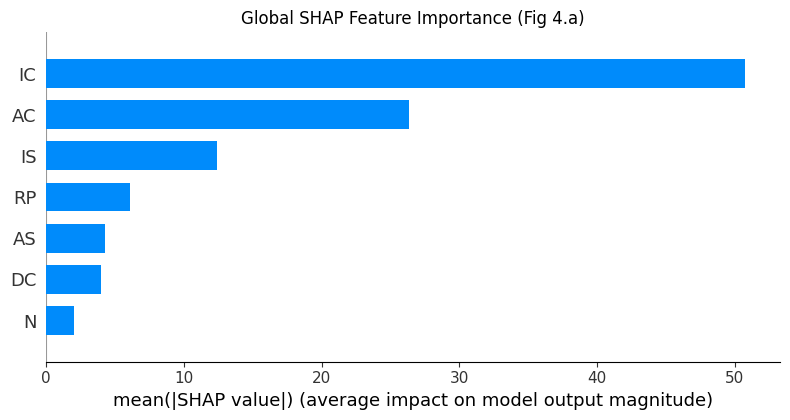

In [44]:
plt.title("Global SHAP Feature Importance (Fig 4.a)")

shap.summary_plot(
    shap_values_matrix, 
    features=features, 
    plot_type="bar", 
    show=True
)

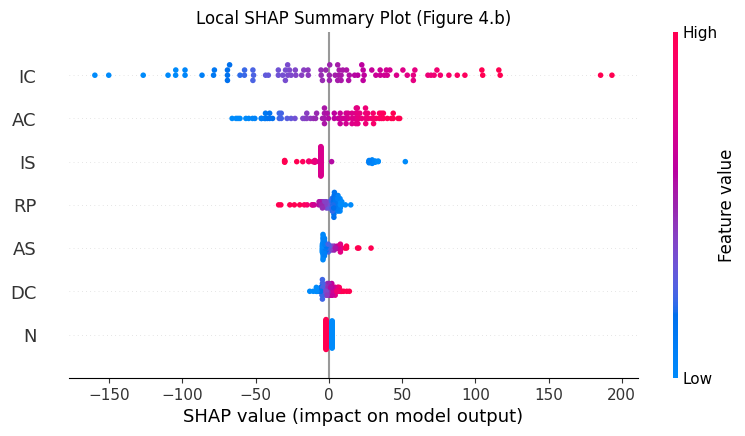

In [45]:
shap.summary_plot(
    df_shap[processed_X.columns].values, 
    features=processed_X,
    show=False # Giữ False để tinh chỉnh thêm bằng matplotlib nếu cần
)
plt.title("Local SHAP Summary Plot (Figure 4.b)")
plt.show()

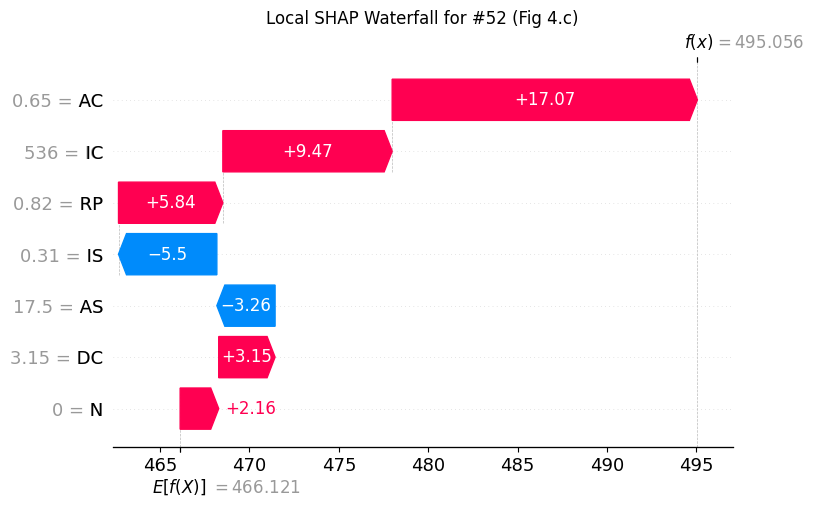

In [46]:
# Chọn 1 dòng dữ liệu bất kỳ để giải thích (Ví dụ: dòng đầu tiên index = 0)
sample_idx = 52


explanation = shap.Explanation(
    values=shap_values_matrix[sample_idx], 
    base_values=base_value, 
    data=processed_X.iloc[sample_idx].values, 
    feature_names=features.tolist()
)

plt.title(f"Local SHAP Waterfall for #{sample_idx} (Fig 4.c)")

# Gọi hàm vẽ waterfall
shap.plots.waterfall(explanation)

## 4.2. <a id='toc4_2_'></a>[Thử nghiệm với bộ dữ liệu khác](#toc0_)

In [47]:
def generalization_test_pipeline(file_path, models, scaler):
    """
    Pipeline kiểm thử khả năng tổng quát hóa của mô hình trên dataset vật liệu mới (vd: Bi@C).
    
    Parameters:
    - file_path (str): Đường dẫn tới file dataset mới (vd: './input/Bi@C.csv').
    - models (list): Danh sách các model đã được train (vd: ada_models_tuned, svr_models_tuned).
    - scaler (StandardScaler): Biến scaler đã được fit trên tập X_train nguyên bản của Sb@C.
    
    Returns:
    - df_preds (DataFrame): Bảng chứa giá trị thực tế, dự đoán của từng model và Ensemble_Avg.
    - df_perm (DataFrame): Bảng chứa Permutation Importance trên tập dữ liệu mới.
    """
    print(f"\n{'='*50}")
    print(f"BẮT ĐẦU PIPELINE KIỂM THỬ TRÊN DATASET MỚI: {file_path}")
    print(f"{'='*50}")

    # 1. LOAD DATASET
    print("[1/4] Đang load dữ liệu...")
    df_new = pd.read_csv(file_path)
    
    # Loại bỏ cột DOI nếu có để đồng nhất cấu trúc
    if "DOI" in df_new.columns:
        df_new = df_new.drop(columns=["DOI"])
        
    # Tách Features (X) và Target (y) theo đúng thứ tự mảng gốc
    X_new = df_new[['AC', 'AS', 'RP', 'IS', 'N', 'IC', 'DC']]
    y_new = df_new['RC']

    # 2. PREPROCESSING 
    # Không apply_cep_method và KNNImputer do dataset mới đã được xử lý sạch sẽ (theo giả định).
    print("[2/4] Feature Engineering... --- IGNORED ---")
    # X_new = feature_extraction_formulas(X_new)

    # 3. SCALING
    # BẮT BUỘC dùng scaler đã fit từ tập train gốc (Sb@C) để transform tập mới
    print("[3/4] Đang chuẩn hóa dữ liệu (StandardScaler)...")
    X_new_scaled = pd.DataFrame(
        scaler.transform(X_new), 
        columns=X_new.columns, 
        index=X_new.index
    )

    # 4. ĐÁNH GIÁ (EVALUATION & PREDICTION)
    # Tái sử dụng hàm evaluate_on_test_set đã định nghĩa
    print("[4/4] Đang chạy Model Prediction & tính toán Metrics...")
    df_preds, df_perm = evaluate_on_test_set(
        models=models, 
        X_test=X_new_scaled, 
        y_test=y_new
    )
    
    # Bổ sung tính Loss Rate trung bình (so sánh với ngưỡng 15% của bài báo)
    # Loss Rate = |Experimental RC - Predicted RC| / Experimental RC
    df_preds['Loss_Rate(%)'] = (abs(df_preds['Actual'] - df_preds['Ensemble_Avg']) / df_preds['Actual']) * 100
    
    print("\n[KẾT LUẬN] Tỷ lệ sai số (Loss Rate) trên vật liệu mới:")
    print(f"-> Loss Rate Trung bình: {df_preds['Loss_Rate(%)'].mean():.2f}%")
    
    return df_preds, df_perm


In [48]:
bi_preds_df, bi_perm_df = generalization_test_pipeline(
    file_path='./input/Fe@C.csv', 
    models=svr_models_tuned,  # Danh sách 10 models AdaBoost từ K-Fold
    scaler=scaler             # Biến scaler dùng lúc train_test_split dữ liệu gốc
)

# In kết quả 5 dòng đầu để kiểm tra
display(bi_preds_df.head())


BẮT ĐẦU PIPELINE KIỂM THỬ TRÊN DATASET MỚI: ./input/Fe@C.csv
[1/4] Đang load dữ liệu...
[2/4] Feature Engineering... --- IGNORED ---
[3/4] Đang chuẩn hóa dữ liệu (StandardScaler)...
[4/4] Đang chạy Model Prediction & tính toán Metrics...

============================== EVALUATION & PERMUTATION IMPORTANCE REPORT ==============================

--- PERFORMANCE METRICS TABLE ---
                  R2      RMSE       MAE
Model                                   
Model_1      -6.2580  147.5904  127.9759
Model_2      -4.1654  124.5092  110.4325
Model_3      -3.1373  111.4307  103.2103
Model_4      -6.4812  149.8421  133.0431
Model_5      -4.2105  125.0519  109.3397
Model_6      -2.8948  108.1166   95.2663
Model_7      -3.5867  117.3273  103.6095
Model_8      -5.0423  134.6641  118.8731
Model_9      -3.8611  120.7853  107.6920
Model_10     -2.8970  108.1470   94.1983
Ensemble_Avg -4.1461  124.2763  110.3641


[KẾT LUẬN] Tỷ lệ sai số (Loss Rate) trên vật liệu mới:
-> Loss Rate Trung bình: 24.18

,Actual,Model_1,Model_2,Model_3,Model_4,Model_5,Model_6,Model_7,Model_8,Model_9,Model_10,Ensemble_Avg,Loss_Rate(%)
0,400.0,177.523895,215.767070,231.857650,167.711405,214.469613,236.589585,223.804453,200.303426,221.527404,235.926949,212.548145,46.862964
1,457.8,400.156286,410.238070,387.598927,405.423277,423.485909,433.336584,430.566327,407.495829,419.165665,438.946261,415.641313,9.208975
2,510.0,333.069696,361.616908,397.826981,351.036803,360.643073,393.480896,381.979435,348.750780,370.110721,394.151591,369.266688,27.594767
3,545.0,599.853657,606.552130,607.324866,633.543821,613.157299,621.672326,627.988029,609.242414,618.771902,623.017851,616.112430,13.048152
